In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [3]:
import os

# Set correct permissions for kaggle.json (read/write for owner only)
kaggle_json_path = '/root/.kaggle/kaggle.json'
os.chmod(kaggle_json_path, 0o600)

print(f"Permissions for '{kaggle_json_path}' set to {oct(os.stat(kaggle_json_path).st_mode & 0o777)}")

Permissions for '/root/.kaggle/kaggle.json' set to 0o600


In [4]:
import os

# Check if kaggle.json exists in the correct directory
kaggle_json_path = '/root/.kaggle/kaggle.json'
if os.path.exists(kaggle_json_path):
    print(f"'{kaggle_json_path}' found. Permissions: {oct(os.stat(kaggle_json_path).st_mode & 0o777)}")
else:
    print(f"'{kaggle_json_path}' NOT found. Please ensure you have uploaded 'kaggle.json' and run the cell to move it.")

'/root/.kaggle/kaggle.json' found. Permissions: 0o600


In [5]:
!pip install kaggle
# Download dataset from Kaggle
!kaggle datasets download -d ninadaithal/imagesoasis

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:11<00:00, 113MB/s]



In [6]:
!unzip imagesoasis.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_102.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_103.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_104.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_105.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_106.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_107.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_108.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_109.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_110.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_111.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_112.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_113.jpg  
  inflating: data/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_114.jpg  
  inflating: 

In [7]:
import os
os.listdir("data/Data")

['Non Demented', 'Very mild Dementia', 'Moderate Dementia', 'Mild Dementia']

(np.float64(-0.5), np.float64(495.5), np.float64(247.5), np.float64(-0.5))

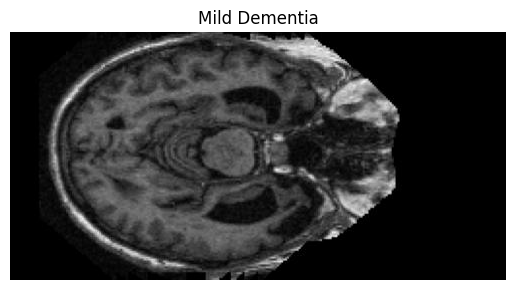

In [8]:
# Visualizing a sample image by correct label.
import matplotlib.pyplot as plt
from PIL import Image
import random

base_path = "data/Data"
category = random.choice(os.listdir(base_path))
img_name = random.choice(os.listdir(os.path.join(base_path, category)))

img_path = os.path.join(base_path, category, img_name)
img = Image.open(img_path)

plt.imshow(img)
plt.title(category)
plt.axis("off")

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [10]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 18
EPOCHS = 17
DATA_DIR = "data/Data"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 69151 images belonging to 4 classes.
Found 17286 images belonging to 4 classes.
Class indices: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}


In [11]:
# Now, Building ResNet50 Alzheimer Model
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# LOAD RESNET50 base model (TRANSFER LEARNING)
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
base_model.trainable = False

# Unfreeze last few layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(4, activation="softmax")(x)

# actual model
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 4,991,236 (19.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [12]:
# Now, using the callbacks for preventing the model from overvitting
callbacks = [
    EarlyStopping(    # Stops training if validation accuracy stops improving
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(     # Saves the best model during training
        "best_resnet_model.h5",
        monitor="val_loss",
        save_best_only=True
    )
]




# Now, training the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Now, saving the Best model
model.save("alzheimer_resnet50_final.h5")
print("Model saved successfully.")

Epoch 1/17
3842/3842 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8090 - loss: 0.5243

3842/3842 ━━━━━━━━━━━━━━━━━━━━ 305s 75ms/step - accuracy: 0.8496 - loss: 0.4067 - val_accuracy: 0.7493 - val_loss: 0.7385
Epoch 2/17
3842/3842 ━━━━━━━━━━━━━━━━━━━━ 303s 72ms/step - accuracy: 0.9496 - loss: 0.1532 - val_accuracy: 0.5981 - val_loss: 1.3295
Epoch 3/17
3842/3842 ━━━━━━━━━━━━━━━━━━━━ 278s 72ms/step - accuracy: 0.9790 - loss: 0.0693 - val_accuracy: 0.7774 - val_loss: 1.5109
Epoch 4/17
3842/3842 ━━━━━━━━━━━━━━━━━━━━ 278s 72ms/step - accuracy: 0.9890 - loss: 0.0387 - val_accuracy: 0.7785 - val_loss: 1.5303


Model saved successfully.


In [13]:
import tensorflow as tf

model = tf.keras.models.load_model("best_resnet_model.h5")
print("Best model loaded successfully")

Best model loaded successfully


Best model loaded successfully!
Found 86437 files belonging to 4 classes.
Using 17287 files for validation.
Class names: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

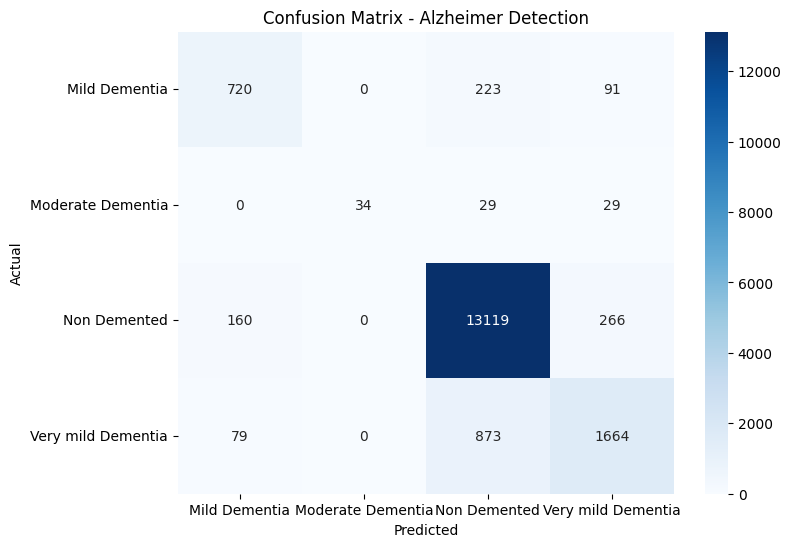


Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.75      0.70      0.72      1034
 Moderate Dementia       1.00      0.37      0.54        92
      Non Demented       0.92      0.97      0.94     13545
Very mild Dementia       0.81      0.64      0.71      2616

          accuracy                           0.90     17287
         macro avg       0.87      0.67      0.73     17287
      weighted avg       0.89      0.90      0.89     17287



In [15]:
from sklearn.utils import validation
# Now, evaluating the model
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Loading the best saved model
model = tf.keras.models.load_model("best_resnet_model.h5")
print("Best model loaded successfully!")

# Recreate validation dataset
DATA_DIR = "/content/data/Data"

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = val_ds.class_names
print("Class names:", class_names)

# Normalization
normalization_layer = tf.keras.layers.Rescaling(1./255)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


# Now, Evaluating the model
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Alzheimer Detection")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
